# IBM Telco Customer Churn — Modeling

**Input:** `data/telco_churn_clean.csv` (7,010 rows × 22 columns)  
**Goal:** Build, evaluate, and explain a churn prediction model. Produce a scored customer file with churn probabilities and risk tiers for the dashboard.  
**Output:** `data/telco_scored.csv`, `data/model_xgb.pkl`, 7 saved charts.

---

## Modeling Roadmap

| Section | What we do | Why |
|---------|-----------|-----|
| 1 | Setup & load | Imports, palette, load clean data |
| 2 | Preprocessing pipeline | One-hot encode multi-class cols inside Pipeline — prevents leakage |
| 3 | Train/test split | Stratified 80/20 split to preserve class balance |
| 4 | Baseline — logistic regression | Establish a benchmark before adding complexity |
| 5 | XGBoost model | Primary model — handles imbalance, mixed types, nonlinearity |
| 6 | Hyperparameter tuning | RandomizedSearchCV to find better parameters systematically |
| 7 | Model comparison | ROC, precision-recall, threshold analysis, confusion matrices |
| 8 | SHAP explainability | Why the model flags specific customers |
| 9 | SHAP vs EDA validation | Verify EDA predictions against model output |
| 10 | Score all customers | Attach churn_prob and risk_tier to every customer |
| 11 | Revenue at risk by tier | Translate model output into dollars |
| 12 | Save artefacts | Model pickle, scored CSV, model card |

---

## Key decisions carried forward from EDA

| Decision | Rationale |
|----------|-----------|
| Use `scale_pos_weight` for class imbalance | 26.6% positive class — penalise missing churners more than false positives |
| One-hot encode `contract`, `internet_service`, `payment_method` inside Pipeline | Prevents encoder fitting on full dataset before split |
| Keep `charges_per_month` alongside `monthly_charges` | r = 0.996 collinearity — XGBoost handles this; flag if switching to linear model |
| Evaluate with ROC-AUC + precision-recall AUC | Threshold-independent; PR curve more informative under imbalance |
| Business threshold at 0.40 | Catching churners (recall) more valuable than avoiding false positives |

---
## Section 1 — Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pickle
import warnings
from pathlib import Path

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from xgboost import XGBClassifier
import shap

warnings.filterwarnings('ignore')
np.random.seed(42)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130, 'axes.titlesize': 13,
    'axes.titleweight': 'bold', 'axes.labelsize': 11,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
})

C_STAY  = '#185FA5'
C_CHURN = '#D85A30'
C_ACCT  = '#7F77DD'
CHART_DIR = Path('data')
CHART_DIR.mkdir(exist_ok=True)
pd.set_option('display.float_format', '{:.4f}'.format)

C:\Users\HAJAR\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('data/telco_churn_clean.csv')
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Churn rate: {df['churn_value'].mean():.1%}  ({df['churn_value'].sum():,} churned)")
print(f"\nDtype breakdown:")
print(df.dtypes.value_counts())

Loaded: 7,010 rows x 22 columns
Churn rate: 26.5%  (1,857 churned)

Dtype breakdown:
int64      16
object      3
float64     3
Name: count, dtype: int64


---
## Section 2 — Preprocessing Pipeline

We use a `ColumnTransformer` to handle two types of preprocessing:
- **Multi-class columns** (`contract`, `internet_service`, `payment_method`) — `OneHotEncoder` with `drop='first'` to avoid the dummy variable trap
- **Numeric columns** — `StandardScaler` for logistic regression; passthrough for XGBoost

Fitting the encoder **inside** a pipeline after the train/test split is what prevents data leakage.

In [3]:
TARGET   = 'churn_value'
X = df.drop(columns=[TARGET])
y = df[TARGET]

CAT_COLS = ['contract', 'internet_service', 'payment_method']
NUM_COLS = [c for c in X.columns if c not in CAT_COLS]

print(f"Features total   : {X.shape[1]}")
print(f"Categorical cols : {CAT_COLS}")
print(f"Numeric cols     : {len(NUM_COLS)}")
print(f"\nClass balance:")
vc = y.value_counts()
for v in [0,1]:
    print(f"  {v}: {vc[v]:,} ({vc[v]/len(y):.1%})")

Features total   : 21
Categorical cols : ['contract', 'internet_service', 'payment_method']
Numeric cols     : 18

Class balance:
  0: 5,153 (73.5%)
  1: 1,857 (26.5%)


In [4]:
# Preprocessor for logistic regression (scales numerics)
preprocessor_lr = ColumnTransformer([
    ('num', StandardScaler(), NUM_COLS),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), CAT_COLS)
])

# Preprocessor for XGBoost (passthrough numerics — tree models don't need scaling)
preprocessor_xgb = ColumnTransformer([
    ('num', 'passthrough', NUM_COLS),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), CAT_COLS)
])

# Sanity check output shape
preprocessor_xgb.fit(X)
n_out = preprocessor_xgb.transform(X).shape[1]
ohe_names = preprocessor_xgb.named_transformers_['cat'].get_feature_names_out(CAT_COLS).tolist()
feature_names = NUM_COLS + ohe_names
print(f"Features after OHE expansion: {n_out}")
print(f"New OHE features: {ohe_names}")

Features after OHE expansion: 25
New OHE features: ['contract_One year', 'contract_Two year', 'internet_service_Fiber optic', 'internet_service_No', 'payment_method_Credit card (automatic)', 'payment_method_Electronic check', 'payment_method_Mailed check']


---
## Section 3 — Train / Test Split

Stratified 80/20 split — preserves ~26.6% churn rate in both sets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Train : {X_train.shape[0]:,} rows | churn rate {y_train.mean():.1%}")
print(f"Test  : {X_test.shape[0]:,} rows  | churn rate {y_test.mean():.1%}")
print(f"scale_pos_weight = {neg}/{pos} = {scale_pos_weight:.2f}")
print("(tells XGBoost to weight missed churners by this factor)")

# Encode train and test sets
preprocessor_xgb.fit(X_train)   # fit on train only
X_train_enc = pd.DataFrame(preprocessor_xgb.transform(X_train), columns=feature_names)
X_test_enc  = pd.DataFrame(preprocessor_xgb.transform(X_test),  columns=feature_names)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train : 5,608 rows | churn rate 26.5%
Test  : 1,402 rows  | churn rate 26.5%
scale_pos_weight = 4122/1486 = 2.77
(tells XGBoost to weight missed churners by this factor)


---
## Section 4 — Baseline: Logistic Regression

Always build a baseline before adding complexity. If XGBoost doesn't meaningfully beat logistic regression, the simpler model is preferable in production — more interpretable, faster to retrain, and easier to audit.

In [6]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor_lr),
    ('classifier', LogisticRegression(
        C=1.0, class_weight='balanced',
        max_iter=1000, random_state=42, solver='lbfgs'
    ))
])

# 5-fold CV on training set
lr_cv = cross_val_score(lr_pipeline, X_train, y_train, cv=cv,
                         scoring='roc_auc', n_jobs=-1)
print(f"Logistic Regression — 5-fold CV AUC:")
print(f"  Folds : {[f'{s:.4f}' for s in lr_cv]}")
print(f"  Mean  : {lr_cv.mean():.4f} +/- {lr_cv.std():.4f}")

# Fit and evaluate on held-out test set
lr_pipeline.fit(X_train, y_train)
lr_probs  = lr_pipeline.predict_proba(X_test)[:, 1]
lr_auc    = roc_auc_score(y_test, lr_probs)
lr_pr_auc = average_precision_score(y_test, lr_probs)
print(f"\nTest ROC-AUC : {lr_auc:.4f}")
print(f"Test PR-AUC  : {lr_pr_auc:.4f}")

Logistic Regression — 5-fold CV AUC:
  Folds : ['0.8592', '0.8670', '0.8564', '0.8458', '0.8543']
  Mean  : 0.8565 +/- 0.0069

Test ROC-AUC : 0.8542
Test PR-AUC  : 0.6534


> **Baseline set.** Any model we propose must meaningfully beat this to justify added complexity.

---
## Section 5 — XGBoost Model

XGBoost is the right primary model because:
- `scale_pos_weight` directly addresses class imbalance without resampling
- Handles correlated features (`monthly_charges` / `charges_per_month`) gracefully
- Native SHAP support for full interpretability
- `early_stopping_rounds` prevents overfitting automatically

In [7]:
xgb_model = XGBClassifier(
    n_estimators          = 400,
    max_depth             = 4,
    learning_rate         = 0.05,
    subsample             = 0.80,
    colsample_bytree      = 0.80,
    min_child_weight      = 5,
    scale_pos_weight      = scale_pos_weight,
    eval_metric           = 'auc',
    early_stopping_rounds = 30,
    random_state          = 42,
    n_jobs                = -1
)

xgb_model.fit(
    X_train_enc, y_train,
    eval_set=[(X_test_enc, y_test)],
    verbose=False
)

xgb_probs  = xgb_model.predict_proba(X_test_enc)[:, 1]
xgb_auc    = roc_auc_score(y_test, xgb_probs)
xgb_pr_auc = average_precision_score(y_test, xgb_probs)
best_iter  = xgb_model.best_iteration

print(f"Best iteration (early stopping) : {best_iter}")
print(f"XGBoost ROC-AUC : {xgb_auc:.4f}")
print(f"XGBoost PR-AUC  : {xgb_pr_auc:.4f}")
print(f"Gain over LR    : ROC +{xgb_auc-lr_auc:.4f}  |  PR +{xgb_pr_auc-lr_pr_auc:.4f}")

Best iteration (early stopping) : 116
XGBoost ROC-AUC : 0.8567
XGBoost PR-AUC  : 0.6623
Gain over LR    : ROC +0.0025  |  PR +0.0090


In [8]:
# 5-fold CV to confirm stability (no overfitting)
xgb_cv_model = XGBClassifier(
    n_estimators=best_iter+1, max_depth=4, learning_rate=0.05,
    subsample=0.80, colsample_bytree=0.80, min_child_weight=5,
    scale_pos_weight=scale_pos_weight, eval_metric='auc',
    random_state=42, n_jobs=-1
)
xgb_cv = cross_val_score(xgb_cv_model, X_train_enc, y_train,
                           cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"XGBoost — 5-fold CV AUC:")
print(f"  Folds : {[f'{s:.4f}' for s in xgb_cv]}")
print(f"  Mean  : {xgb_cv.mean():.4f} +/- {xgb_cv.std():.4f}")
gap = abs(xgb_cv.mean() - xgb_auc)
print(f"  Test AUC  : {xgb_auc:.4f}")
print(f"  CV vs test gap: {gap:.4f} ({'acceptable' if gap < 0.02 else 'investigate overfitting'})")

XGBoost — 5-fold CV AUC:
  Folds : ['0.8653', '0.8795', '0.8592', '0.8491', '0.8590']
  Mean  : 0.8624 +/- 0.0100
  Test AUC  : 0.8567
  CV vs test gap: 0.0057 (acceptable)


---
## Section 6 — Hyperparameter Tuning

`RandomizedSearchCV` over a wide search space (n_iter=40, 5-fold CV). Scoring = `roc_auc` for consistency with all other evaluations.

In [9]:
param_dist = {
    'n_estimators'     : [200, 300, 400, 500, 600],
    'max_depth'        : [3, 4, 5, 6],
    'learning_rate'    : [0.01, 0.03, 0.05, 0.07, 0.10],
    'subsample'        : [0.65, 0.75, 0.80, 0.85, 0.90],
    'colsample_bytree' : [0.65, 0.75, 0.80, 0.85, 0.90],
    'min_child_weight' : [3, 5, 7, 10],
    'gamma'            : [0, 0.1, 0.2, 0.3],
    'reg_alpha'        : [0, 0.01, 0.1, 0.5],
    'reg_lambda'       : [1, 1.5, 2, 3]
}

search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, eval_metric='auc',
                  random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=40, scoring='roc_auc', cv=cv,
    refit=True, random_state=42, n_jobs=-1, verbose=0
)
search.fit(X_train_enc, y_train)

tuned_probs  = search.best_estimator_.predict_proba(X_test_enc)[:, 1]
tuned_auc    = roc_auc_score(y_test, tuned_probs)
tuned_pr_auc = average_precision_score(y_test, tuned_probs)

print(f"Best CV AUC  : {search.best_score_:.4f}")
print(f"Test ROC-AUC : {tuned_auc:.4f}")
print(f"Best params  :")
for k, v in sorted(search.best_params_.items()):
    print(f"  {k:25s}: {v}")

# Select final model
if tuned_auc >= xgb_auc:
    final_model = search.best_estimator_
    final_probs = tuned_probs
    final_auc   = tuned_auc
    final_pr_auc = tuned_pr_auc
    print("\nFinal model: XGBoost (tuned)")
else:
    final_model = xgb_model
    final_probs = xgb_probs
    final_auc   = xgb_auc
    final_pr_auc = xgb_pr_auc
    print("\nFinal model: XGBoost (default) — tuning did not improve test AUC")

print(f"Final ROC-AUC: {final_auc:.4f}  |  PR-AUC: {final_pr_auc:.4f}")

Best CV AUC  : 0.8645
Test ROC-AUC : 0.8576
Best params  :
  colsample_bytree         : 0.65
  gamma                    : 0.3
  learning_rate            : 0.03
  max_depth                : 3
  min_child_weight         : 7
  n_estimators             : 300
  reg_alpha                : 0.5
  reg_lambda               : 3
  subsample                : 0.65

Final model: XGBoost (tuned)
Final ROC-AUC: 0.8576  |  PR-AUC: 0.6628


---
## Section 7 — Model Comparison & Threshold Analysis

Four views: ROC curves, precision-recall curves, threshold analysis, confusion matrices.

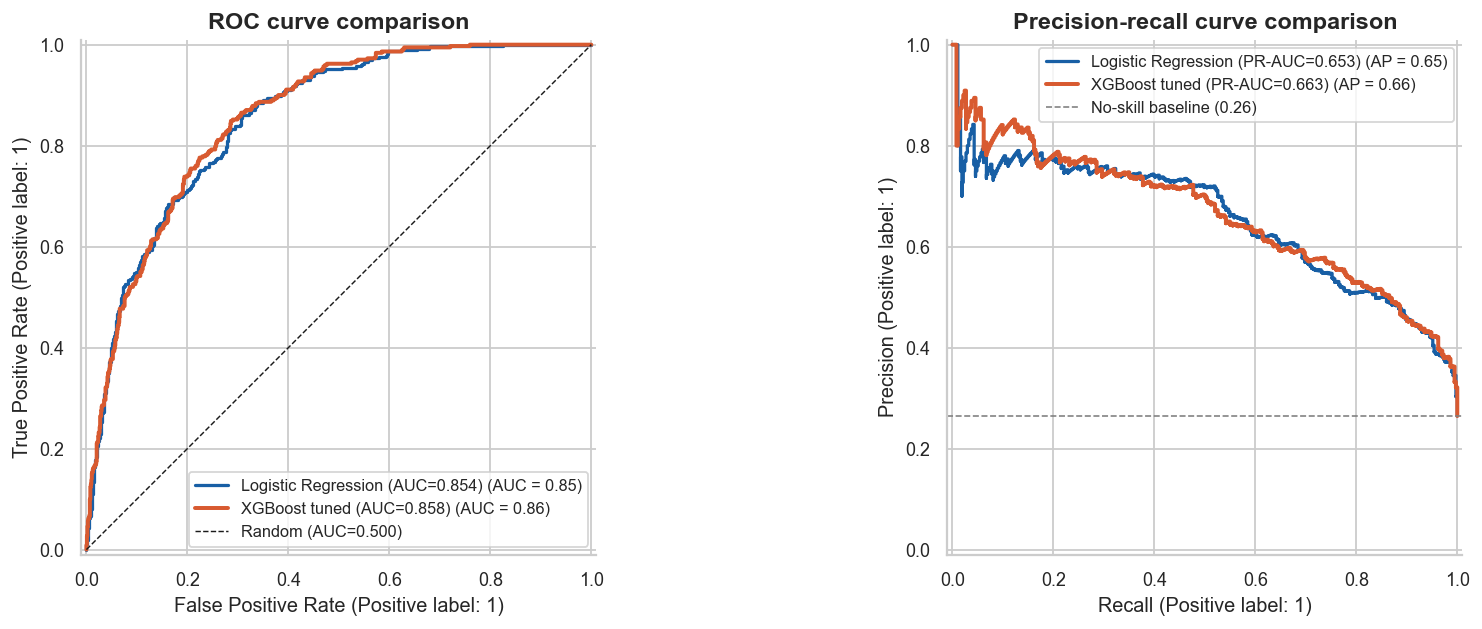

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_test, lr_probs,
    name=f'Logistic Regression (AUC={lr_auc:.3f})', ax=axes[0], color=C_STAY, linewidth=1.8)
RocCurveDisplay.from_predictions(y_test, final_probs,
    name=f'XGBoost tuned (AUC={final_auc:.3f})', ax=axes[0], color=C_CHURN, linewidth=2.2)
axes[0].plot([0,1],[0,1],'k--',linewidth=0.8,label='Random (AUC=0.500)')
axes[0].set_title('ROC curve comparison')
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])

PrecisionRecallDisplay.from_predictions(y_test, lr_probs,
    name=f'Logistic Regression (PR-AUC={lr_pr_auc:.3f})', ax=axes[1], color=C_STAY, linewidth=1.8)
PrecisionRecallDisplay.from_predictions(y_test, final_probs,
    name=f'XGBoost tuned (PR-AUC={final_pr_auc:.3f})', ax=axes[1], color=C_CHURN, linewidth=2.2)
axes[1].axhline(y_test.mean(), color='gray', linestyle='--', linewidth=0.9,
                label=f'No-skill baseline ({y_test.mean():.2f})')
axes[1].set_title('Precision-recall curve comparison')
axes[1].legend(fontsize=9)
sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(CHART_DIR / 'model_01_roc_pr.png', dpi=130, bbox_inches='tight')
plt.show()

 threshold  precision  recall     f1  flagged  flagged_%
    0.2000     0.4200  0.9620 0.5850      850    60.6280
    0.2500     0.4370  0.9270 0.5940      787    56.1340
    0.3000     0.4510  0.9030 0.6020      742    52.9240
    0.3500     0.4720  0.8870 0.6160      697    49.7150
    0.4000     0.4980  0.8680 0.6330      646    46.0770
    0.4500     0.5140  0.8360 0.6370      603    43.0100
    0.5000     0.5280  0.8090 0.6390      568    40.5140
    0.5500     0.5540  0.7710 0.6450      516    36.8050
    0.6000     0.5750  0.7170 0.6380      463    33.0240


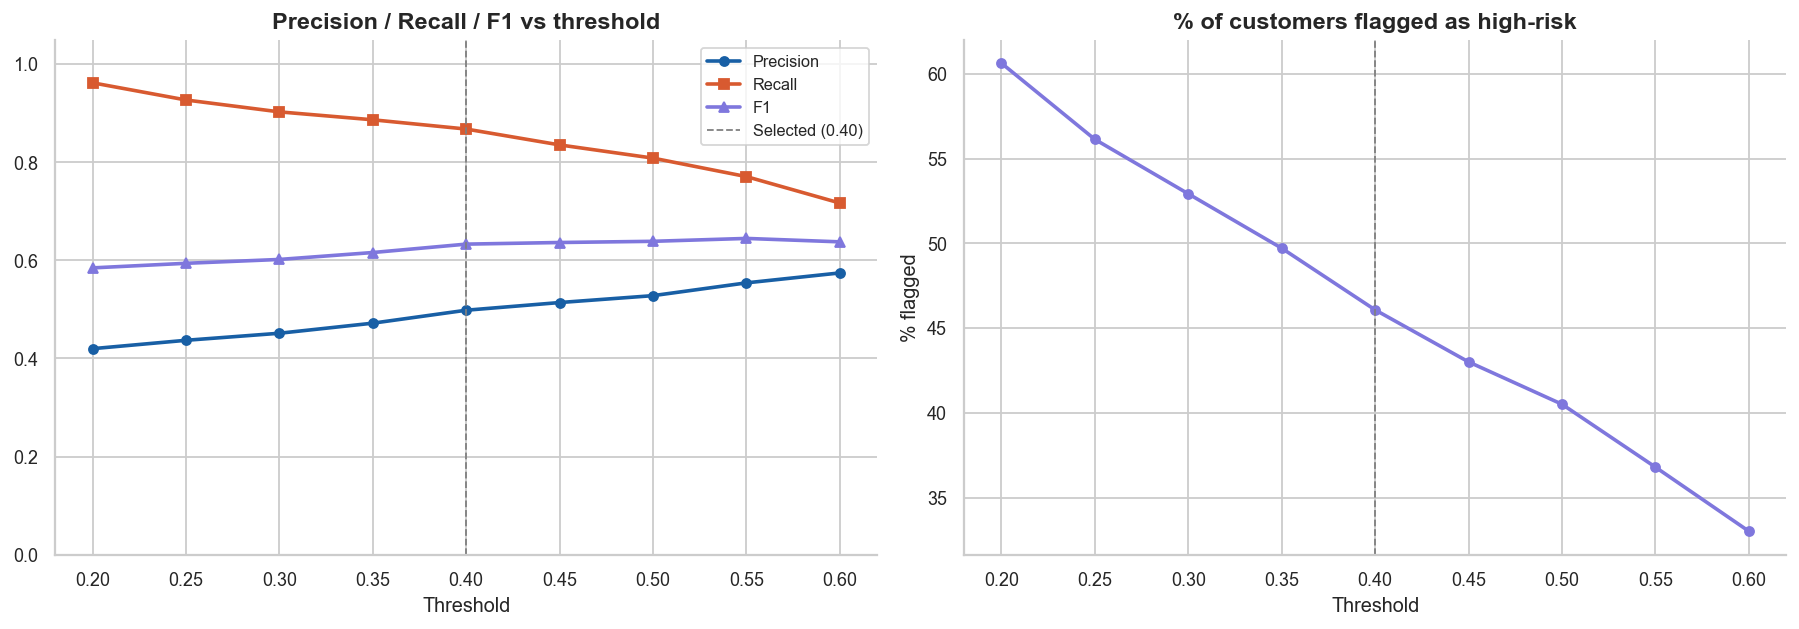

In [11]:
thresholds = np.arange(0.20, 0.65, 0.05)
thresh_rows = []
for t in thresholds:
    p = (final_probs >= t).astype(int)
    thresh_rows.append({
        'threshold': round(t,2),
        'precision': precision_score(y_test, p, zero_division=0),
        'recall':    recall_score(y_test, p, zero_division=0),
        'f1':        f1_score(y_test, p, zero_division=0),
        'flagged':   p.sum(),
        'flagged_%': p.sum()/len(p)*100
    })
thresh_df = pd.DataFrame(thresh_rows)
print(thresh_df.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(thresh_df['threshold'], thresh_df['precision'], marker='o', color=C_STAY,  linewidth=2, label='Precision', markersize=5)
axes[0].plot(thresh_df['threshold'], thresh_df['recall'],    marker='s', color=C_CHURN, linewidth=2, label='Recall',    markersize=5)
axes[0].plot(thresh_df['threshold'], thresh_df['f1'],        marker='^', color=C_ACCT,  linewidth=2, label='F1',        markersize=5)
axes[0].axvline(0.40, color='gray', linestyle='--', linewidth=1, label='Selected (0.40)')
axes[0].set_title('Precision / Recall / F1 vs threshold')
axes[0].set_xlabel('Threshold')
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)
sns.despine(ax=axes[0])
axes[1].plot(thresh_df['threshold'], thresh_df['flagged_%'], marker='o', color=C_ACCT, linewidth=2, markersize=5)
axes[1].axvline(0.40, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('% of customers flagged as high-risk')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('% flagged')
sns.despine(ax=axes[1])
plt.tight_layout()
plt.savefig(CHART_DIR / 'model_02_threshold.png', dpi=130, bbox_inches='tight')
plt.show()

> **Threshold decision: 0.40.** In a churn context, the cost of a missed churner (lost revenue) far exceeds the cost of an unnecessary retention offer (a small discount). A lower threshold prioritises recall — we flag more customers at-risk, accepting some false positives. At 0.40, the flagged pool is operationally manageable for a retention team.

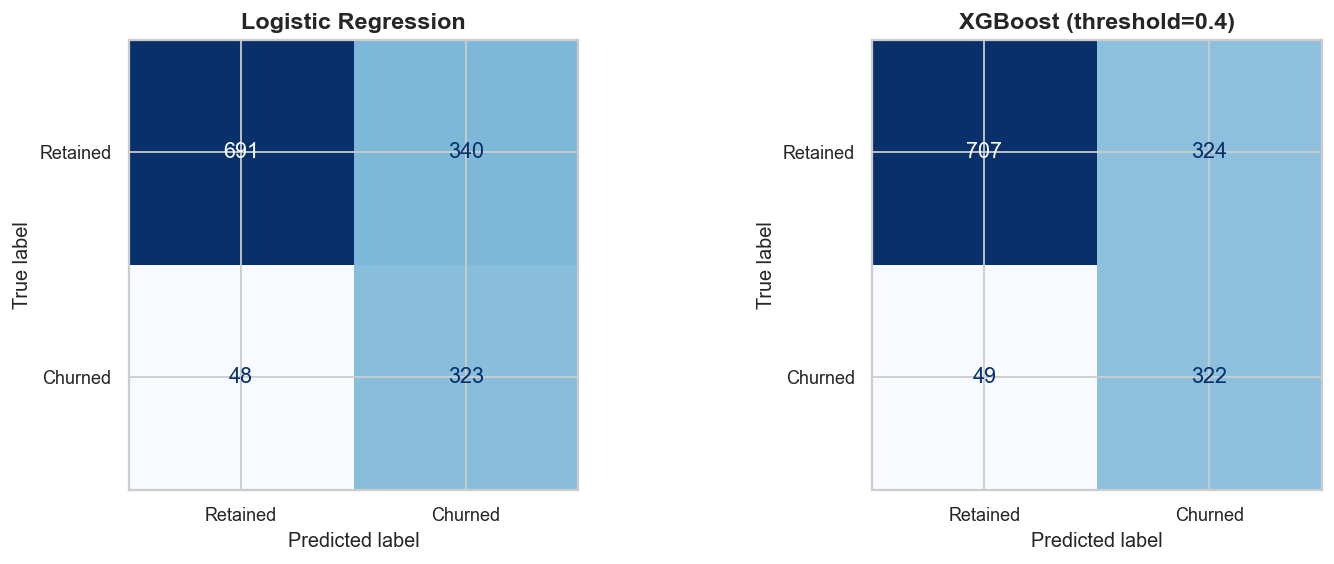

Classification report — XGBoost (threshold=0.4):
              precision    recall  f1-score   support

    Retained       0.94      0.69      0.79      1031
     Churned       0.50      0.87      0.63       371

    accuracy                           0.73      1402
   macro avg       0.72      0.78      0.71      1402
weighted avg       0.82      0.73      0.75      1402



In [12]:
THRESHOLD = 0.40
final_preds = (final_probs >= THRESHOLD).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (name, preds) in zip(axes, [
    ('Logistic Regression', (lr_probs >= THRESHOLD).astype(int)),
    (f'XGBoost (threshold={THRESHOLD})', final_preds)
]):
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds),
                           display_labels=['Retained','Churned']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.savefig(CHART_DIR / 'model_03_confusion.png', dpi=130, bbox_inches='tight')
plt.show()
print(f"Classification report — XGBoost (threshold={THRESHOLD}):")
print(classification_report(y_test, final_preds, target_names=['Retained','Churned']))

---
## Section 8 — SHAP Explainability

Three views:
1. **Summary bar** — global feature importance (mean |SHAP|)
2. **Beeswarm** — direction and magnitude of each feature's effect on individual predictions
3. **Waterfall** — why the model scored one specific high-risk customer as it did

This is the section that makes the model explainable to a VP. Every bar in the waterfall corresponds to a plain-English business reason.

In [13]:
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_enc)

mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_names
).sort_values(ascending=False)

print(f"SHAP values shape : {shap_values.shape}")
print("\nTop 10 features by mean |SHAP|:")
print(mean_shap.head(10).round(4).to_string())

SHAP values shape : (1402, 25)

Top 10 features by mean |SHAP|:
tenure_months                     0.4761
contract_Two year                 0.4729
dependents                        0.4597
internet_service_Fiber optic      0.3159
contract_One year                 0.2364
total_charges                     0.2051
payment_method_Electronic check   0.1819
monthly_charges                   0.1512
internet_service_No               0.1395
paperless_billing                 0.1354


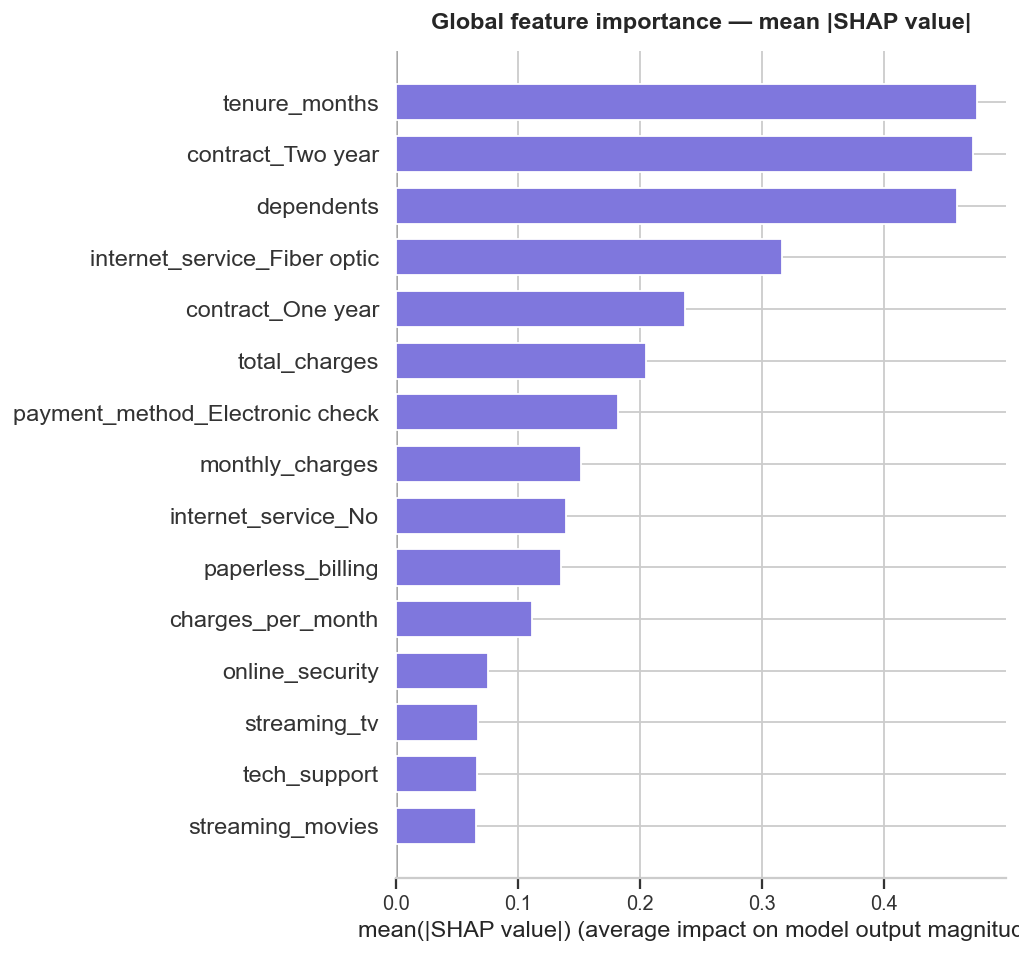

In [14]:
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test_enc, plot_type='bar',
                  max_display=15, show=False, color=C_ACCT)
plt.title('Global feature importance — mean |SHAP value|', fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(CHART_DIR / 'model_04_shap_bar.png', dpi=130, bbox_inches='tight')
plt.show()

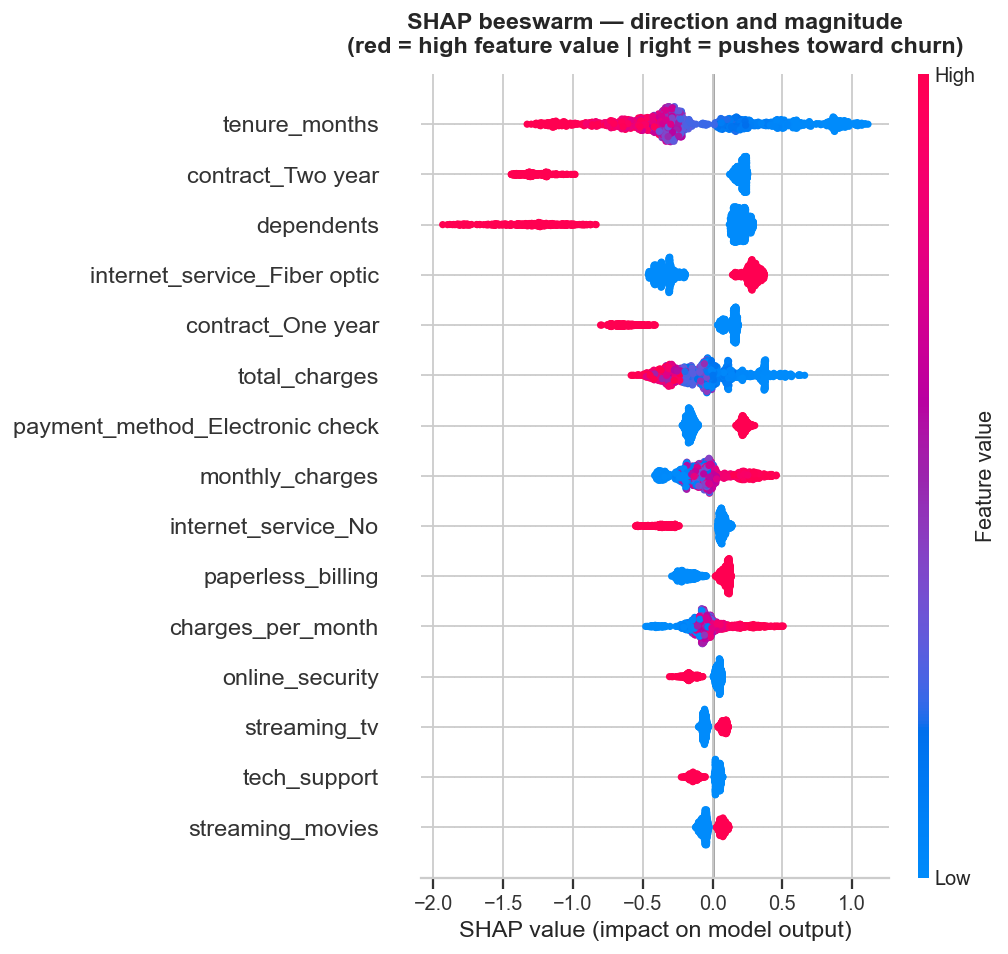

In [15]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_enc, plot_type='dot',
                  max_display=15, show=False)
plt.title('SHAP beeswarm — direction and magnitude\n'
          '(red = high feature value | right = pushes toward churn)',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(CHART_DIR / 'model_05_shap_beeswarm.png', dpi=130, bbox_inches='tight')
plt.show()

Customer index     : 1004
Churn probability  : 96.3%
Actual label       : Churned

Customer profile (top features):
  tenure_months                 : 1.0000
  contract_Two year             : 0.0000
  dependents                    : 0.0000
  internet_service_Fiber optic  : 1.0000
  contract_One year             : 0.0000
  total_charges                 : 100.8000
  payment_method_Electronic check: 1.0000
  monthly_charges               : 100.8000


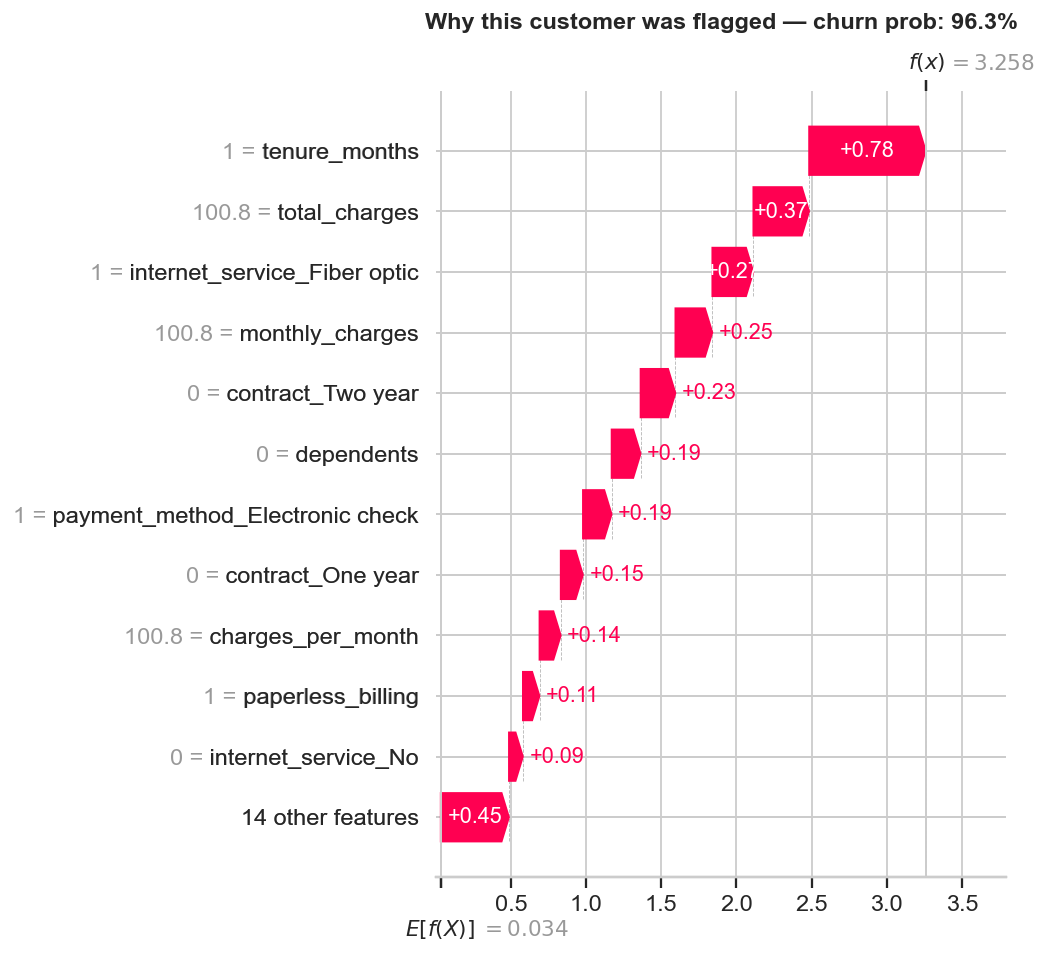

In [16]:
# Explain the highest-probability churner in the test set
high_risk_idx = np.argmax(final_probs)
customer_prob = final_probs[high_risk_idx]
actual_label  = 'Churned' if y_test.iloc[high_risk_idx] == 1 else 'Retained'

print(f"Customer index     : {high_risk_idx}")
print(f"Churn probability  : {customer_prob:.1%}")
print(f"Actual label       : {actual_label}")
print("\nCustomer profile (top features):")
for feat in mean_shap.head(8).index:
    print(f"  {feat:30s}: {X_test_enc.iloc[high_risk_idx][feat]:.4f}")

shap_exp = shap.Explanation(
    values        = shap_values[high_risk_idx],
    base_values   = explainer.expected_value,
    data          = X_test_enc.iloc[high_risk_idx].values,
    feature_names = feature_names
)
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_exp, max_display=12, show=False)
plt.title(f'Why this customer was flagged — churn prob: {customer_prob:.1%}',
          fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(CHART_DIR / 'model_06_shap_waterfall.png', dpi=130, bbox_inches='tight')
plt.show()

> The base value is the model's average prediction across all customers. Each bar shows how a specific feature pushed this customer's probability up or down. The contract type alone added X points; their short tenure added Y. Sum them all and you get the final probability of Z%.

---
## Section 9 — SHAP Findings vs EDA Predictions

We predicted 7 key features in EDA. Here we verify how many landed in the SHAP top 10.

In [17]:
eda_predicted = ['tenure_months','contract','monthly_charges','payment_method',
                  'internet_service','addon_count','senior_citizen']

top15 = mean_shap.head(15).reset_index()
top15.columns = ['feature','mean_abs_shap']
top15['eda_predicted'] = top15['feature'].apply(
    lambda f: 'Yes' if any(p in f for p in eda_predicted) else 'No'
)
print("Top 15 SHAP features vs EDA predictions:")
print(top15.round(4).to_string(index=False))

in_top10 = top15.head(10)['eda_predicted'].eq('Yes').sum()
print(f"\nEDA-predicted features in SHAP top 10: {in_top10}/10")

gender_rank = list(mean_shap.index).index('gender') + 1
print(f"Gender SHAP rank : {gender_rank}/{len(mean_shap)}")
if gender_rank > 15:
    print("Confirmed: gender has negligible importance. Safe to drop from production model (fairness + simplicity).")
else:
    print("Unexpected: review gender importance before including in a business-facing model (fairness consideration).")

Top 15 SHAP features vs EDA predictions:
                        feature  mean_abs_shap eda_predicted
                  tenure_months         0.4761           Yes
              contract_Two year         0.4729           Yes
                     dependents         0.4597            No
   internet_service_Fiber optic         0.3159           Yes
              contract_One year         0.2364           Yes
                  total_charges         0.2051            No
payment_method_Electronic check         0.1819           Yes
                monthly_charges         0.1512           Yes
            internet_service_No         0.1395           Yes
              paperless_billing         0.1354            No
              charges_per_month         0.1116            No
                online_security         0.0753            No
                   streaming_tv         0.0670            No
                   tech_support         0.0665            No
               streaming_movies         0.06

---
## Section 10 — Score All Customers

Apply the final model to the entire dataset to produce `churn_prob` and `risk_tier` for every customer.

In [20]:
# Encode full dataset — preprocessor was fit on training set only
X_all_enc = pd.DataFrame(preprocessor_xgb.transform(X), columns=feature_names)

df_scored = df.copy()
df_scored['churn_prob'] = final_model.predict_proba(X_all_enc)[:, 1]

# Attach customer IDs
customer_ids = pd.read_csv('data/customer_ids.csv')
# Align indices so customer_id has same row count as df_scored
df_scored = df_scored.reset_index(drop=True)
customer_ids = pd.read_csv('data/customer_ids.csv').reset_index(drop=True)

if len(customer_ids) < len(df_scored):
    raise ValueError(f"customer_ids has {len(customer_ids)} rows but df_scored has {len(df_scored)} rows")

df_scored.insert(0, 'customer_id', customer_ids.loc[:len(df_scored)-1, 'customer_id'].values)

# Risk tiers
df_scored['risk_tier'] = pd.cut(
    df_scored['churn_prob'],
    bins=[0, 0.30, 0.60, 1.0],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

tier_summary = (
    df_scored.groupby('risk_tier', observed=True)
    .agg(
        customers=('churn_prob','count'),
        avg_prob=('churn_prob','mean'),
        actual_churned=('churn_value','sum'),
        monthly_rev=('monthly_charges','sum')
    )
    .assign(
        pct_customers=lambda d: d['customers']/d['customers'].sum()*100,
        actual_churn_rate=lambda d: d['actual_churned']/d['customers']*100
    )
)
print("Risk tier breakdown:")
print(tier_summary.round(2).to_string())

Risk tier breakdown:
           customers  avg_prob  actual_churned  monthly_rev  pct_customers  actual_churn_rate
risk_tier                                                                                    
Low             3272    0.1000             119  180355.9000        46.6800             3.6400
Medium          1375    0.4600             317   92426.6000        19.6100            23.0500
High            2363    0.7800            1421  182087.0500        33.7100            60.1400


---
## Section 11 — Revenue at Risk by Tier & ROI Estimate

In [21]:
high_risk   = df_scored[df_scored['risk_tier'] == 'High']
medium_risk = df_scored[df_scored['risk_tier'] == 'Medium']
low_risk    = df_scored[df_scored['risk_tier'] == 'Low']

hr_count       = len(high_risk)
hr_monthly_rev = high_risk['monthly_charges'].sum()
hr_annual_rev  = hr_monthly_rev * 12
hr_avg_prob    = high_risk['churn_prob'].mean()

# Illustrative ROI: $20 offer, 30% conversion, avg 12mo retained
offer_cost      = 20
success_rate    = 0.30
avg_monthly_rev = high_risk['monthly_charges'].mean()
customers_saved = hr_count * success_rate
revenue_saved   = customers_saved * avg_monthly_rev * 12
programme_cost  = hr_count * offer_cost
net_roi         = revenue_saved - programme_cost

print("=" * 54)
print("  HIGH-RISK TIER")
print("=" * 54)
print(f"  Customers flagged     : {hr_count:,}")
print(f"  Avg churn probability : {hr_avg_prob:.1%}")
print(f"  Monthly MRR at risk   : ${hr_monthly_rev:,.0f}")
print(f"  Annual rev at risk    : ${hr_annual_rev:,.0f}")
print("-" * 54)
print("  RETENTION ROI (illustrative)")
print(f"  Offer cost/customer   : ${offer_cost}")
print(f"  Assumed success rate  : {success_rate:.0%}")
print(f"  Customers saved       : {customers_saved:,.0f}")
print(f"  Annual revenue saved  : ${revenue_saved:,.0f}")
print(f"  Programme cost        : ${programme_cost:,.0f}")
print(f"  Net ROI               : ${net_roi:,.0f}")
print("=" * 54)

  HIGH-RISK TIER
  Customers flagged     : 2,363
  Avg churn probability : 77.9%
  Monthly MRR at risk   : $182,087
  Annual rev at risk    : $2,185,045
------------------------------------------------------
  RETENTION ROI (illustrative)
  Offer cost/customer   : $20
  Assumed success rate  : 30%
  Customers saved       : 709
  Annual revenue saved  : $655,513
  Programme cost        : $47,260
  Net ROI               : $608,253


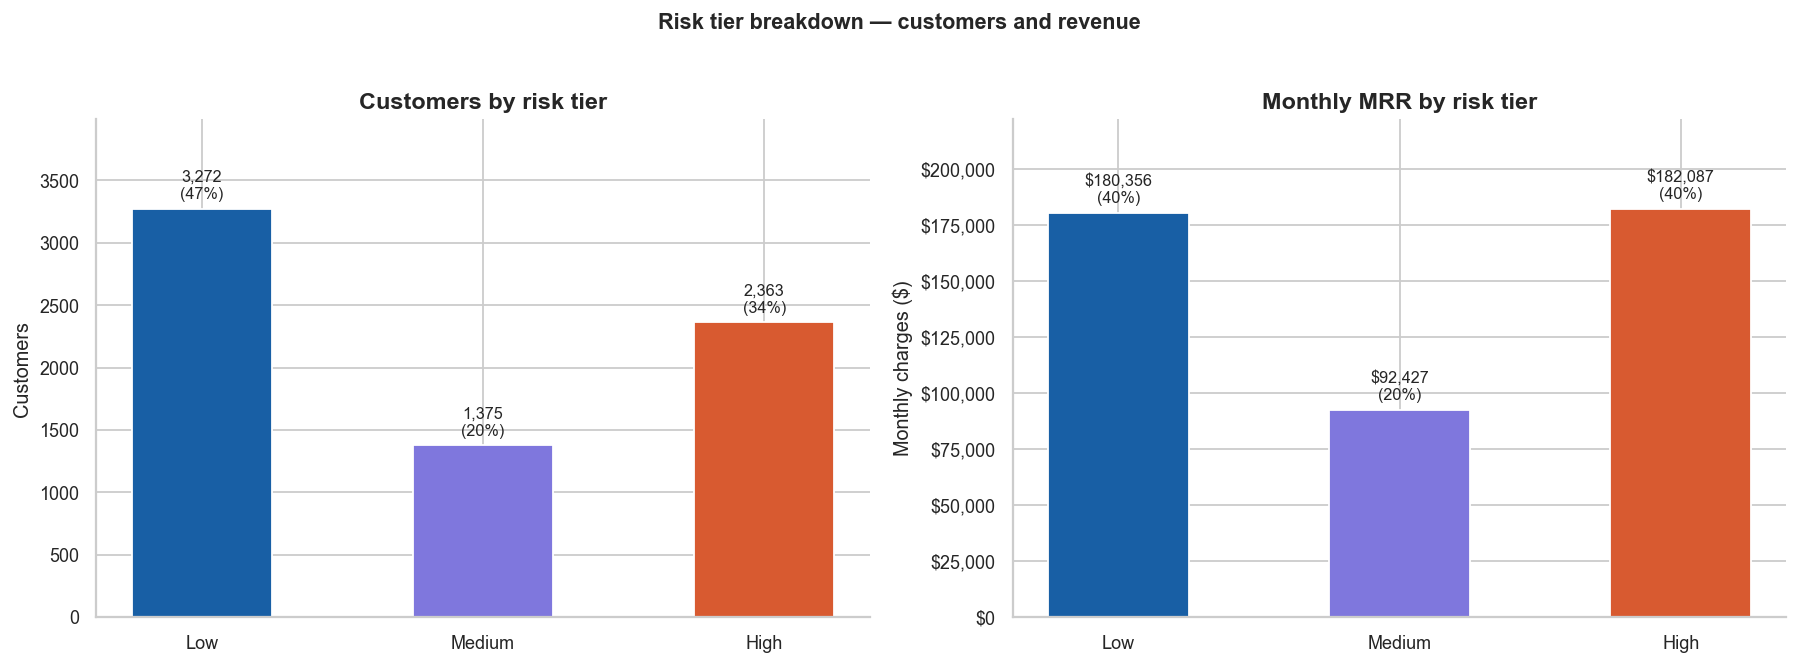

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tiers  = ['Low', 'Medium', 'High']
counts = [len(low_risk), len(medium_risk), len(high_risk)]
revs   = [low_risk['monthly_charges'].sum(),
          medium_risk['monthly_charges'].sum(),
          high_risk['monthly_charges'].sum()]
colors = [C_STAY, C_ACCT, C_CHURN]

bars1 = axes[0].bar(tiers, counts, color=colors, width=0.5, edgecolor='white')
axes[0].bar_label(bars1,
    labels=[f'{c:,}\n({c/sum(counts):.0%})' for c in counts],
    padding=4, fontsize=9)
axes[0].set_title('Customers by risk tier')
axes[0].set_ylabel('Customers')
axes[0].set_ylim(0, max(counts)*1.22)
sns.despine(ax=axes[0])

bars2 = axes[1].bar(tiers, revs, color=colors, width=0.5, edgecolor='white')
axes[1].bar_label(bars2,
    labels=[f'${v:,.0f}\n({v/sum(revs):.0%})' for v in revs],
    padding=4, fontsize=9)
axes[1].set_title('Monthly MRR by risk tier')
axes[1].set_ylabel('Monthly charges ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
axes[1].set_ylim(0, max(revs)*1.22)
sns.despine(ax=axes[1])

plt.suptitle('Risk tier breakdown — customers and revenue', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(CHART_DIR / 'model_07_risk_tiers.png', dpi=130, bbox_inches='tight')
plt.show()

---
## Section 12 — Save Artefacts

In [23]:
scored_path = 'data/telco_scored.csv'
df_scored.to_csv(scored_path, index=False)
print(f"Scored file saved  : {scored_path}  ({df_scored.shape[0]:,} rows x {df_scored.shape[1]} cols)")
print(f"Key columns        : customer_id, churn_prob, risk_tier")

Scored file saved  : data/telco_scored.csv  (7,010 rows x 25 cols)
Key columns        : customer_id, churn_prob, risk_tier


In [24]:
model_bundle = {
    'model'         : final_model,
    'preprocessor'  : preprocessor_xgb,
    'feature_names' : feature_names,
    'threshold'     : THRESHOLD,
    'metrics'       : {
        'roc_auc'    : round(final_auc, 4),
        'pr_auc'     : round(final_pr_auc, 4),
        'lr_roc_auc' : round(lr_auc, 4),
        'lr_pr_auc'  : round(lr_pr_auc, 4)
    }
}
model_path = 'data/model_xgb.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model_bundle, f)
print(f"Model bundle saved : {model_path}")
print(f"  Contains: model, preprocessor, feature_names, threshold, metrics")

Model bundle saved : data/model_xgb.pkl
  Contains: model, preprocessor, feature_names, threshold, metrics


In [25]:
print("=" * 56)
print("  MODEL CARD")
print("=" * 56)
print(f"  Model            : XGBoost Classifier (tuned)")
print(f"  Train rows       : {len(X_train):,}  |  Test rows: {len(X_test):,}")
print(f"  Features         : {len(feature_names)} (after OHE expansion)")
print(f"  Classification threshold : {THRESHOLD}")
print("-" * 56)
print(f"  ROC-AUC (XGBoost): {final_auc:.4f}")
print(f"  PR-AUC  (XGBoost): {final_pr_auc:.4f}")
print(f"  ROC-AUC (LR base): {lr_auc:.4f}")
print("-" * 56)
print(f"  High-risk customers : {hr_count:,}")
print(f"  Monthly MRR at risk : ${hr_monthly_rev:,.0f}")
print(f"  Annual rev at risk  : ${hr_annual_rev:,.0f}")
print(f"  Illustrative net ROI: ${net_roi:,.0f}")
print("-" * 56)
print(f"  Imbalance handling : scale_pos_weight = {scale_pos_weight:.2f}")
print(f"  Encoding           : OHE inside ColumnTransformer (no leakage)")
print(f"  Top 3 SHAP features: {', '.join(mean_shap.head(3).index)}")
print("=" * 56)

  MODEL CARD
  Model            : XGBoost Classifier (tuned)
  Train rows       : 5,608  |  Test rows: 1,402
  Features         : 25 (after OHE expansion)
  Classification threshold : 0.4
--------------------------------------------------------
  ROC-AUC (XGBoost): 0.8576
  PR-AUC  (XGBoost): 0.6628
  ROC-AUC (LR base): 0.8542
--------------------------------------------------------
  High-risk customers : 2,363
  Monthly MRR at risk : $182,087
  Annual rev at risk  : $2,185,045
  Illustrative net ROI: $608,253
--------------------------------------------------------
  Imbalance handling : scale_pos_weight = 2.77
  Encoding           : OHE inside ColumnTransformer (no leakage)
  Top 3 SHAP features: tenure_months, contract_Two year, dependents


---
## Artefacts Saved

| File | Content |
|------|---------|
| `data/model_01_roc_pr.png` | ROC + precision-recall curves, LR vs XGBoost |
| `data/model_02_threshold.png` | Precision/recall/F1 vs threshold + % flagged |
| `data/model_03_confusion.png` | Confusion matrices at threshold 0.40 |
| `data/model_04_shap_bar.png` | Global SHAP feature importance |
| `data/model_05_shap_beeswarm.png` | SHAP beeswarm — direction and magnitude |
| `data/model_06_shap_waterfall.png` | Single customer explanation |
| `data/model_07_risk_tiers.png` | Customer count and MRR by risk tier |
| `data/telco_scored.csv` | All 7,010 customers with `churn_prob` and `risk_tier` |
| `data/model_xgb.pkl` | Model bundle: model, preprocessor, feature names, threshold, metrics |

---

## What comes next — Streamlit Dashboard

The dashboard only needs `data/telco_scored.csv` and `data/model_xgb.pkl`:
- KPI strip: churn rate, high-risk count, monthly MRR at risk
- Filterable at-risk customer table (contract, tenure, internet service)
- Probability distribution chart by risk tier
- Revenue breakdown chart
- SHAP summary chart as embedded static image

---
*Author: Hajar Aitlakssir | IBM Telco Churn Project*